In [55]:
import torch
import os
from pathlib import Path
import json
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from sklearn.preprocessing import StandardScaler

In [34]:
# Constants
LAYER = "decoder.model.decoder.layers.0"
METADATA_PATH = "/home/harinit9/orcd/pool/musicgen-data-nokey/dataset_metadata.json"

In [97]:
# NOTE: change this to data dir as appropriate
N_CLIPS = 500

with open(METADATA_PATH) as fin:
    metadata = json.load(fin)[:1000]

print(f"Loading {len(metadata)} clips")

def get_clip_np(clip: dict, layer: str = LAYER):
    """
    Retrieve the activations for a single clip idx
    """
    act_path = clip["activations_path"]
    acts = torch.load(act_path)
    layer_acts = torch.cat(acts[layer], dim=1)
    
    # Return guided guy
    return layer_acts.numpy()[0]

X_raw = np.stack([
    get_clip_np(metadata[i]) for i in tqdm(range(len(metadata)))
])
print(X_raw.shape)

Loading 1000 clips


100%|██████████| 1000/1000 [18:41<00:00,  1.12s/it]


(1000, 256, 2048)


In [139]:
# Get labels
from sklearn.preprocessing import OneHotEncoder

all_keys = sorted(set([clip["key_info"]["mode"] for clip in metadata]))
n_classes = len(all_keys)

y_raw = np.array([
    all_keys.index(clip["key_info"]["mode"])
    for clip in metadata
])
y_onehot = np.eye(n_classes)[y_raw]
print(y_raw[:10])

[0 0 1 1 1 0 1 1 1 0]


In [140]:
# Make train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y_raw, test_size=0.3, stratify=y_raw
)

(1000, 256, 2048)


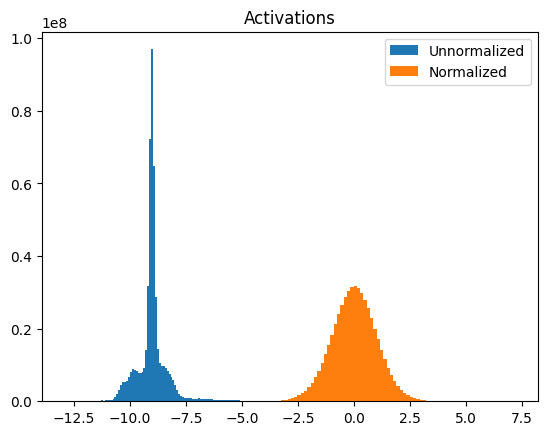

In [ ]:
# Bad! unnormalized data
scaler = StandardScaler()

X_norm = (X_raw - X_raw_mean) / X_raw_std
print(X_norm.shape)

plt.hist(X_raw.flatten(), bins=100, label="Unnormalized")
plt.hist(X_norm.flatten(), bins=100, label="Normalized")
plt.legend()
plt.title("Activations");

In [134]:
# Flatten for linear regression
X_flat = X_norm.reshape(len(X_norm), -1)
print(X_flat.shape)

(1000, 524288)


In [131]:
# Train a linear probe
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_flat, y_onehot)

LinearRegression()

In [132]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# class_labels = ["major", "minor"]
class_labels = all_keys

y_pred = np.argmax(reg.predict(X_flat), axis=1)

cm = confusion_matrix(y_pred, y_raw)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot()

<Figure size 640x480 with 2 Axes>